In [89]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)

In [90]:
import pandas as pd

# Charger le dataset
df = pd.read_csv("/content/Examen_travel_planning_dataset.csv")

print(f"Lignes   : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")
print(df.dtypes)

Lignes   : 1500
Colonnes : 15
trip_id                        int64
client_type                   object
budget_total                 float64
destination                   object
saison                        object
duree_jours                    int64
type_hebergement              object
prix_vol                     float64
meteo_prevue                  object
activite_principale           object
satisfaction_client          float64
imprevus                      object
reorganisation_necessaire      int64
respect_budget                 int64
retour_client                 object
dtype: object


exploration rapide

In [91]:
resume_brut = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "valeurs_manquantes": df.isna().sum(),
    "pourcentage_manquant": (df.isna().sum() / len(df) * 100).round(2),
    "valeurs_uniques": df.nunique(dropna=True),
})

display(resume_brut)

print("Doublons exacts :", int(df.duplicated().sum()))
print("Doublons trip_id :", int(df["trip_id"].duplicated().sum()))

,type,valeurs_manquantes,pourcentage_manquant,valeurs_uniques
trip_id,int64,0,0.00,1500
client_type,object,0,0.00,5
budget_total,float64,40,2.67,1419
destination,object,0,0.00,8
saison,object,0,0.00,4
duree_jours,int64,0,0.00,23
type_hebergement,object,36,2.40,4
prix_vol,float64,53,3.53,1429
meteo_prevue,object,39,2.60,4
activite_principale,object,48,3.20,5


Doublons exacts : 0
Doublons trip_id : 0


,valeurs_manquantes,pourcentage
prix_vol,53,3.53
imprevus,53,3.53
activite_principale,48,3.20
budget_total,40,2.67
meteo_prevue,39,2.60
type_hebergement,36,2.40
satisfaction_client,25,1.67
retour_client,25,1.67


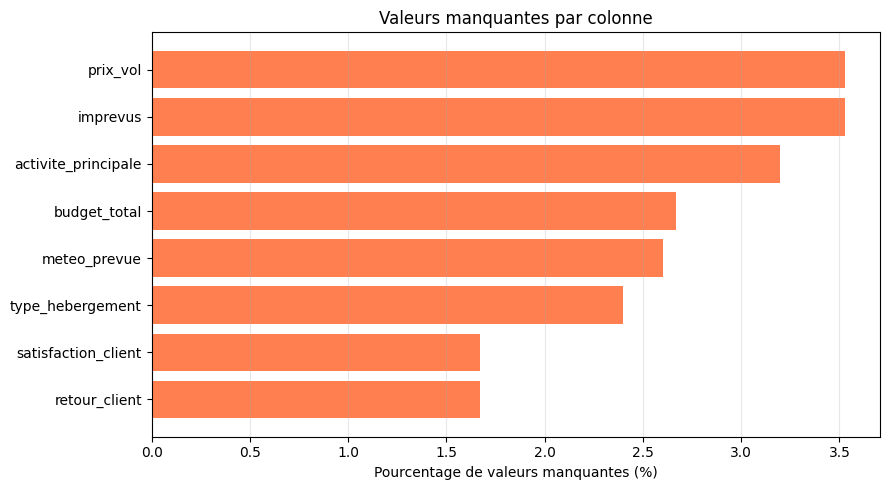

In [92]:
missing_summary = (
    df.isna().sum()
    .to_frame("valeurs_manquantes")
)
missing_summary["pourcentage"] = (missing_summary["valeurs_manquantes"] / len(df) * 100).round(2)
missing_summary = missing_summary[missing_summary["valeurs_manquantes"] > 0].sort_values("valeurs_manquantes", ascending=False)

display(missing_summary)

if not missing_summary.empty:
    plt.figure(figsize=(9, 5))
    plt.barh(missing_summary.index[::-1], missing_summary["pourcentage"][::-1], color="coral")
    plt.xlabel("Pourcentage de valeurs manquantes (%)")
    plt.title("Valeurs manquantes par colonne")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Analyse métier des données

Fonctions réutilisables

In [93]:
# Fonctions utilitaires utilisées dans tout le notebook

def normaliser_texte(serie):
    """Standardise les textes pour faciliter les comparaisons métier."""
    return serie.fillna("").astype(str).str.strip().str.lower()


def afficher_cas(df_cas, colonnes=None, n=10):
    """Affiche le nombre de cas détectés puis un échantillon lisible."""
    print(f"Nombre de cas détectés : {len(df_cas)}")
    if len(df_cas) == 0:
        print("Aucun cas à afficher.")
        return

    if colonnes is not None:
        display(df_cas[colonnes].head(n))
    else:
        display(df_cas.head(n))


colonnes_principales = [
    "trip_id", "client_type", "budget_total", "destination", "saison",
    "duree_jours", "type_hebergement", "prix_vol", "meteo_prevue",
    "activite_principale", "satisfaction_client", "imprevus",
    "reorganisation_necessaire", "respect_budget"
]

satisfaction invalides

1. Cohérence de la satisfaction client

Observation métier

Le cahier des charges indique que `satisfaction_client` est un score de 1 à 5.

Les valeurs inférieures à 1, supérieures à 5 ou manquantes sont donc incohérentes avec la définition officielle de la variable.

Ces cas doivent être corrigés, exclus ou documentés avant d'utiliser `satisfaction_client` comme cible IA.

In [94]:
df_brut = df
satisfaction_invalide = df_brut[
    (df_brut["satisfaction_client"] > 5) | (df_brut["satisfaction_client"] < 1)
].copy()

afficher_cas(
    satisfaction_invalide,
    ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
)

Nombre de cas détectés : 5


,trip_id,client_type,destination,satisfaction_client,imprevus,retour_client
800,801,couple,Paris,6.0,aucun,Très bon rapport qualité-prix.
811,812,solo,Rome,6.0,aucun,"Très satisfait, je recommande."
812,813,solo,Bali,0.0,retard_vol,À éviter.
1047,1048,business,New York,7.0,météo,"Quelques imprévus, globalement bien."
1102,1103,solo,Sydney,6.0,retard_vol,Déçu par l'organisation.


prix du vol > budget total

In [95]:
vol_superieur_budget = df_brut[
    df_brut["prix_vol"].notna()
    & df_brut["budget_total"].notna()
    & (df_brut["prix_vol"] > df_brut["budget_total"])
].copy()

vol_superieur_budget["ecart_vol_budget"] = (
    vol_superieur_budget["budget_total"] - vol_superieur_budget["prix_vol"]
).round(2)

print("Tous les cas où le prix du vol dépasse le budget total :")
afficher_cas(
    vol_superieur_budget.sort_values("ecart_vol_budget", ascending=False),
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

print("\nCas contradictoires : prix_vol > budget_total ET respect_budget = 1")
vol_superieur_budget_respecte = vol_superieur_budget[vol_superieur_budget["respect_budget"] == 1]
afficher_cas(
    vol_superieur_budget_respecte,
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

Tous les cas où le prix du vol dépasse le budget total :
Nombre de cas détectés : 52


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
1006,1007,senior,Tokyo,993.15,1016.61,-23.46,0
1182,1183,business,Sydney,1087.02,1125.18,-38.16,0
230,231,business,Dubaï,1388.56,1444.72,-56.16,1
17,18,solo,Rome,870.18,930.60,-60.42,0
1264,1265,couple,Rome,1278.80,1343.84,-65.04,0
1260,1261,famille,Rome,852.31,968.46,-116.15,0
1044,1045,senior,Bali,500.00,736.74,-236.74,0
863,864,business,Tokyo,500.00,751.24,-251.24,0
831,832,solo,Sydney,1081.32,1332.76,-251.44,0
998,999,solo,Lisbonne,1067.82,1321.61,-253.79,0



Cas contradictoires : prix_vol > budget_total ET respect_budget = 1
Nombre de cas détectés : 5


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
7,8,couple,Rome,1173.19,1694.67,-521.48,1
216,217,business,Rome,1147.25,1438.08,-290.83,1
230,231,business,Dubaï,1388.56,1444.72,-56.16,1
887,888,solo,Dubaï,380.00,1023.17,-643.17,1
1384,1385,famille,Lisbonne,4152.93,5200.00,-1047.07,1


budget journalier

In [96]:
budget_journalier = df_brut[
    df_brut["budget_total"].notna()
    & df_brut["duree_jours"].notna()
    & (df_brut["duree_jours"] > 0)
].copy()

budget_journalier["budget_par_jour"] = (
    budget_journalier["budget_total"] / budget_journalier["duree_jours"]
).round(2)

budget_journalier_faible = budget_journalier[budget_journalier["budget_par_jour"] < 100]
budget_journalier_eleve = budget_journalier[budget_journalier["budget_par_jour"] > 1000]

print("Budget journalier inférieur à 100 € :")
afficher_cas(
    budget_journalier_faible.sort_values("budget_par_jour"),
    ["trip_id", "client_type", "destination", "budget_total", "duree_jours", "budget_par_jour", "type_hebergement"]
)

print("\nClients de type 'famille' ou 'couple' avec budget journalier < 100 € :")
clients_famille_couple = budget_journalier[
    budget_journalier["client_type"].isin(["famille", "couple"]) &
    (budget_journalier["budget_par_jour"] < 100)
].copy()
# Sort by 'famille' first then 'couple'
clients_famille_couple["client_type"] = pd.Categorical(clients_famille_couple["client_type"], categories=["famille", "couple"], ordered=True)
afficher_cas(
    clients_famille_couple.sort_values("client_type"),
    ["trip_id", "client_type", "destination", "budget_total", "duree_jours", "budget_par_jour", "type_hebergement"]
)


Budget journalier inférieur à 100 € :
Nombre de cas détectés : 47


,trip_id,client_type,destination,budget_total,duree_jours,budget_par_jour,type_hebergement
1450,1451,couple,Rome,500.0,21,23.81,hôtel
902,903,famille,Rome,500.0,20,25.00,resort
1168,1169,couple,Lisbonne,500.0,18,27.78,appartement
948,949,couple,New York,500.0,18,27.78,villa
1483,1484,solo,Tokyo,500.0,16,31.25,villa
1040,1041,senior,New York,500.0,15,33.33,villa
1051,1052,famille,Rome,500.0,15,33.33,appartement
818,819,famille,New York,500.0,15,33.33,appartement
894,895,solo,Bali,500.0,15,33.33,hôtel
1287,1288,couple,Rome,500.0,15,33.33,NaN



Clients de type 'famille' ou 'couple' avec budget journalier < 100 € :
Nombre de cas détectés : 21


,trip_id,client_type,destination,budget_total,duree_jours,budget_par_jour,type_hebergement
1051,1052,famille,Rome,500.00,15,33.33,appartement
818,819,famille,New York,500.00,15,33.33,appartement
1413,1414,famille,Tokyo,637.34,16,39.83,appartement
834,835,famille,New York,1265.55,14,90.40,appartement
1368,1369,famille,Paris,500.00,14,35.71,hôtel
877,878,famille,Bali,500.00,14,35.71,hôtel
902,903,famille,Rome,500.00,20,25.00,resort
1260,1261,famille,Rome,852.31,16,53.27,hôtel
954,955,famille,Rome,500.00,12,41.67,appartement
1144,1145,famille,Dubaï,500.00,13,38.46,resort


Client_type business et activité principale business

In [97]:
client_type_norm = normaliser_texte(df_brut["client_type"])
activite_norm = normaliser_texte(df_brut["activite_principale"])

business_activite_non_business = df_brut[
    (client_type_norm == "business")
    & (activite_norm != "business")
    & (activite_norm != "")
].copy()

non_business_activite_business = df_brut[
    (client_type_norm != "business")
    & (client_type_norm != "")
    & (activite_norm == "business")
].copy()

print("Clients business avec une activité principale non-business :")
afficher_cas(
    business_activite_non_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

print("\nClients non-business avec une activité principale business :")
afficher_cas(
    non_business_activite_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

Clients business avec une activité principale non-business :
Nombre de cas détectés : 200


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
1,2,business,Rome,printemps,randonnée,3288.27,4.0
14,15,business,New York,été,randonnée,12985.57,4.0
19,20,business,Tokyo,printemps,plage,10416.72,3.0
27,28,business,Lisbonne,été,culture,10572.54,5.0
29,30,business,Dubaï,été,culture,2403.24,4.0
34,35,business,Bali,hiver,gastronomie,7427.80,1.0
37,38,business,New York,printemps,plage,13023.12,5.0
40,41,business,Tokyo,été,culture,5227.96,2.0
41,42,business,Tokyo,été,randonnée,5142.10,5.0
44,45,business,Tokyo,été,culture,4100.91,3.0



Clients non-business avec une activité principale business :
Nombre de cas détectés : 122


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
10,11,senior,Bali,automne,business,12845.33,5.0
15,16,solo,Rome,automne,business,6125.88,1.0
16,17,senior,New York,hiver,business,8193.32,2.0
20,21,famille,Bali,automne,business,8186.44,2.0
23,24,solo,Dubaï,automne,business,13391.63,5.0
25,26,couple,Lisbonne,hiver,business,954.98,1.0
42,43,solo,New York,printemps,business,13696.57,2.0
47,48,couple,Lisbonne,hiver,business,9297.44,5.0
71,72,solo,Sydney,hiver,business,2187.78,3.0
129,130,solo,Tokyo,hiver,business,4161.07,3.0


activité principale et météo risquée

In [98]:
meteo_norm = normaliser_texte(df_brut["meteo_prevue"])
activites_exterieures = ["plage", "randonnée", "randonnee"]
meteos_risquees = ["pluie"]

activites_meteo_risque = df_brut[
    activite_norm.isin(activites_exterieures)
    & meteo_norm.isin(meteos_risquees)
    & (df_brut["reorganisation_necessaire"] == 0)
].copy()

afficher_cas(
    activites_meteo_risque,
    ["trip_id", "destination", "saison", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)


Nombre de cas détectés : 66


,trip_id,destination,saison,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
125,126,Rome,automne,pluie,plage,météo,0,2.0
220,221,Paris,hiver,pluie,plage,aucun,0,2.0
247,248,Bali,automne,pluie,randonnée,météo,0,3.0
259,260,Sydney,hiver,pluie,plage,aucun,0,1.0
272,273,Bali,automne,pluie,plage,météo,0,2.0
312,313,Bali,hiver,pluie,plage,aucun,0,3.0
315,316,Rome,automne,pluie,plage,aucun,0,1.0
316,317,New York,printemps,pluie,plage,météo,0,2.0
324,325,Bali,automne,pluie,randonnée,retard_vol,0,3.0
330,331,Bali,automne,pluie,plage,aucun,0,1.0


cohérence entre imprévu et réorganisation

In [99]:
imprevus_norm = normaliser_texte(df_brut["imprevus"])

aucun_imprevu_mais_reorganisation = df_brut[
    (imprevus_norm == "aucun")
    & (df_brut["reorganisation_necessaire"] == 1)
].copy()

print("Aucun imprévu déclaré mais réorganisation nécessaire :")
afficher_cas(
    aucun_imprevu_mais_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Aucun imprévu déclaré mais réorganisation nécessaire :
Nombre de cas détectés : 19


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
78,79,Bali,ensoleillé,gastronomie,aucun,1,3.0
135,136,Bali,ensoleillé,plage,aucun,1,3.0
136,137,New York,nuageux,business,aucun,1,4.0
262,263,Lisbonne,pluie,gastronomie,aucun,1,3.0
363,364,Bali,ensoleillé,gastronomie,aucun,1,5.0
395,396,New York,ensoleillé,randonnée,aucun,1,2.0
417,418,Rome,pluie,business,aucun,1,2.0
473,474,Dubaï,pluie,business,aucun,1,2.0
490,491,Lisbonne,nuageux,culture,aucun,1,5.0
496,497,Paris,pluie,plage,aucun,1,2.0


In [100]:
selection_traitement_modele = pd.DataFrame([
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "impact_modele": "Impact critique sur la cible y",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Supprimer les lignes sans cible ou hors échelle 1-5, sauf justification métier de recodage"
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "impact_modele": "Crée des relations budgétaires impossibles et fausse les ratios",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Identifier les cas, corriger si possible ; sinon exclure ou créer un indicateur d'anomalie"
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "impact_modele": "Contradiction métier forte entre budget et résultat",
        "decision": "Traiter obligatoirement si respect_budget est utilisé",
        "traitement_recommande": "Corriger respect_budget ou exclure ces lignes des modèles utilisant cette variable"
    },
    {
        "controle": "Variables post-séjour : imprevus, reorganisation_necessaire, respect_budget, retour_client",
        "impact_modele": "Risque majeur de fuite de données si la prédiction est faite avant le départ",
        "decision": "Exclure des features du modèle principal",
        "traitement_recommande": "Ne pas les mettre dans X pour prédire satisfaction_client avant voyage ; les garder pour l'analyse explicative"
    },
])

display(selection_traitement_modele)

,controle,impact_modele,decision,traitement_recommande
0,Satisfaction hors échelle ou manquante,Impact critique sur la cible y,Traiter obligatoirement,Supprimer les lignes sans cible ou hors échell...
1,Prix du vol supérieur au budget total,Crée des relations budgétaires impossibles et ...,Traiter obligatoirement,"Identifier les cas, corriger si possible ; sin..."
2,Prix du vol > budget total et respect_budget = 1,Contradiction métier forte entre budget et rés...,Traiter obligatoirement si respect_budget est ...,Corriger respect_budget ou exclure ces lignes ...
3,"Variables post-séjour : imprevus, reorganisati...",Risque majeur de fuite de données si la prédic...,Exclure des features du modèle principal,Ne pas les mettre dans X pour prédire satisfac...


In [101]:
controle_satisfaction = df_brut[
    df_brut["satisfaction_client"].isna()
    | ~df_brut["satisfaction_client"].between(1, 5)
].copy()

controle_prix_budget = df_brut[
    df_brut["prix_vol"].notna()
    & df_brut["budget_total"].notna()
    & (df_brut["prix_vol"] > df_brut["budget_total"])
].copy()

controle_prix_budget_respect = controle_prix_budget[
    controle_prix_budget["respect_budget"] == 1
].copy()

synthese_incoherences = pd.DataFrame([
    {
        "controle": "satisfaction_client manquante ou hors échelle 1-5",
        "nb_lignes": len(controle_satisfaction),
        "traitement": "suppression des lignes concernées"
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_lignes": len(controle_prix_budget),
        "traitement": "suppression des lignes concernées"
    },
    {
        "controle": "prix_vol > budget_total et respect_budget = 1",
        "nb_lignes": len(controle_prix_budget_respect),
        "traitement": "déjà couvert par le contrôle prix_vol > budget_total"
    },
    {
        "controle": "variables post-séjour dans les features",
        "nb_lignes": np.nan,
        "traitement": "exclusion de X pour éviter la fuite de données"
    },
])

display(synthese_incoherences)

,controle,nb_lignes,traitement
0,satisfaction_client manquante ou hors échelle 1-5,30.0,suppression des lignes concernées
1,prix_vol > budget_total,52.0,suppression des lignes concernées
2,prix_vol > budget_total et respect_budget = 1,5.0,déjà couvert par le contrôle prix_vol > budget...
3,variables post-séjour dans les features,NaN,exclusion de X pour éviter la fuite de données


In [102]:
print("Cas satisfaction_client à exclure :")
display(
    controle_satisfaction[
        ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
    ].head(10)
)
print("Cas prix_vol > budget_total à exclure :")
display(
    controle_prix_budget[
        ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "respect_budget", "satisfaction_client"]
    ].sort_values(["budget_total", "prix_vol"]).head(10)
)

Cas satisfaction_client à exclure :


,trip_id,client_type,destination,satisfaction_client,imprevus,retour_client
765,766,couple,Bali,NaN,annulation,Une expérience inoubliable.
771,772,solo,Tokyo,NaN,bagages,À éviter.
778,779,couple,Rome,NaN,annulation,Déçu par l'organisation.
800,801,couple,Paris,6.0,aucun,Très bon rapport qualité-prix.
801,802,famille,Dubaï,NaN,aucun,Une expérience inoubliable.
811,812,solo,Rome,6.0,aucun,"Très satisfait, je recommande."
812,813,solo,Bali,0.0,retard_vol,À éviter.
826,827,couple,Sydney,NaN,météo,Déçu par l'organisation.
835,836,famille,Dubaï,NaN,météo,Excellent séjour.
858,859,famille,Paris,NaN,retard_vol,Très mauvaise expérience.


Cas prix_vol > budget_total à exclure :


,trip_id,client_type,destination,budget_total,prix_vol,respect_budget,satisfaction_client
1451,1452,couple,Rome,380.0,840.02,0,3.0
887,888,solo,Dubaï,380.0,1023.17,1,3.0
868,869,solo,Tokyo,450.0,1206.41,0,2.0
1044,1045,senior,Bali,500.0,736.74,0,2.0
863,864,business,Tokyo,500.0,751.24,0,4.0
818,819,famille,New York,500.0,826.62,0,4.0
1021,1022,couple,Tokyo,500.0,841.02,0,5.0
1029,1030,senior,New York,500.0,843.01,0,3.0
1347,1348,business,New York,500.0,907.05,0,4.0
823,824,couple,Bali,500.0,907.54,0,3.0


In [103]:
df_model = df_brut.copy()

nb_initial = len(df_model)

# 1. Cible valide uniquement : satisfaction_client entre 1 et 5
mask_target_valid = (
    df_model["satisfaction_client"].notna()
    & df_model["satisfaction_client"].between(1, 5)
)
df_model = df_model[mask_target_valid].copy()
nb_after_target = len(df_model)

# 2. Cohérence budgétaire : le prix du vol ne doit pas dépasser le budget total
mask_budget_valid = (
    df_model["prix_vol"].isna()
    | df_model["budget_total"].isna()
    | (df_model["prix_vol"] <= df_model["budget_total"])
)
df_model = df_model[mask_budget_valid].copy()
nb_after_budget = len(df_model)

rapport_nettoyage = pd.DataFrame([
    {
        "etape": "Dataset brut",
        "nb_lignes": nb_initial,
        "lignes_supprimees": 0
    },
    {
        "etape": "Cible satisfaction_client valide",
        "nb_lignes": nb_after_target,
        "lignes_supprimees": nb_initial - nb_after_target
    },
    {
        "etape": "Cohérence prix_vol <= budget_total",
        "nb_lignes": nb_after_budget,
        "lignes_supprimees": nb_after_target - nb_after_budget
    },
])

display(rapport_nettoyage)
print(f"Volume final pour modélisation : {len(df_model)} lignes")

,etape,nb_lignes,lignes_supprimees
0,Dataset brut,1500,0
1,Cible satisfaction_client valide,1470,30
2,Cohérence prix_vol <= budget_total,1418,52


Volume final pour modélisation : 1418 lignes


Préparation des données

In [104]:
# Détection des doublons = absence de doublons dans ce dataset
df.duplicated().sum()

np.int64(0)

In [105]:
#Vérifier l'unicité des valeurs de chaque colonne
df.nunique().sort_values(ascending=False)

,0
trip_id,1500
prix_vol,1429
budget_total,1419
duree_jours,23
retour_client,15
destination,8
satisfaction_client,8
imprevus,5
activite_principale,5
client_type,5


In [106]:
numeric_columns = df_model[["budget_total", "duree_jours", "prix_vol"]]

In [107]:
# Traiter les outliers en premier pour que la médiane soit propre quand on remplacera
#les valeurs manquantes

for col in numeric_columns:
    Q1          = df_model[col].quantile(0.25)
    Q3          = df_model[col].quantile(0.75)
    IQR         = Q3 - Q1
    mediane     = df_model[col].median()
    borne_haute = Q3 + 1.5 * IQR
    borne_basse = Q1 - 1.5 * IQR

    # Compter les outliers
    nb = df_model[(df_model[col] > borne_haute) |
            (df_model[col] < borne_basse)].shape[0]
    print(f"{col:20} → {nb} outliers détectés")

    # Remplacer par la médiane
    df_model.loc[df_model[col] > borne_haute, col] = mediane
    df_model.loc[df_model[col] < borne_basse, col] = mediane

print("\n✅ Outliers traités")

budget_total         → 14 outliers détectés
duree_jours          → 4 outliers détectés
prix_vol             → 16 outliers détectés

✅ Outliers traités


In [108]:
# détecter les valeurs manquantes
missing_values = pd.DataFrame({
    "valeurs_manquantes": df.isna().sum(),
    "pourcentage": (df.isna().sum() / len(df) * 100).round(2)})

missing_values[missing_values["valeurs_manquantes"] > 0].sort_values(
    "valeurs_manquantes",
    ascending=False)

,valeurs_manquantes,pourcentage
prix_vol,53,3.53
imprevus,53,3.53
activite_principale,48,3.20
budget_total,40,2.67
meteo_prevue,39,2.60
type_hebergement,36,2.40
satisfaction_client,25,1.67
retour_client,25,1.67


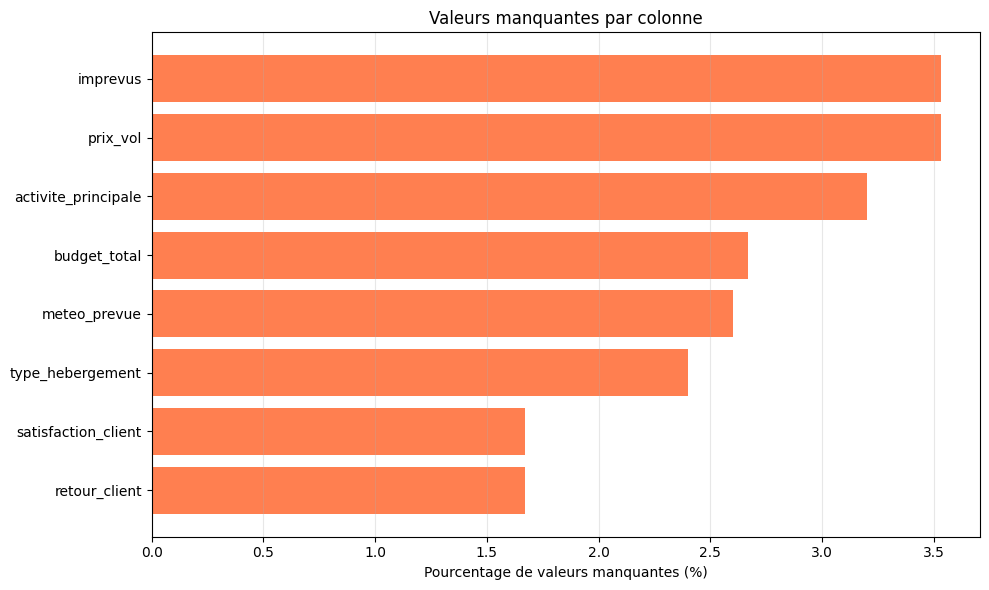

In [109]:
# Visualiser les valeurs manquantes
missing_df_plot = pd.DataFrame({
    "Colonne": missing_values.index,
    "Nombre": missing_values["valeurs_manquantes"],
    "Pourcentage": missing_values["pourcentage"]})

missing_df_plot = missing_df_plot[missing_df_plot["Nombre"] > 0]
missing_df_plot = missing_df_plot.sort_values("Pourcentage", ascending=True)

# Visualisation des valeurs manquantes
plt.figure(figsize=(10, 6))
plt.barh(missing_df_plot["Colonne"], missing_df_plot["Pourcentage"], color="coral")

plt.xlabel("Pourcentage de valeurs manquantes (%)")
plt.title("Valeurs manquantes par colonne")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Traitement des valeurs manquantes

In [110]:
# Valeurs numériques → imputation par la médiane
# La médiane est plus robuste que la moyenne car insensible aux outliers
df_model["budget_total"] = df_model["budget_total"].fillna(df_model["budget_total"].median())
df_model["prix_vol"]     = df_model["prix_vol"].fillna(df_model["prix_vol"].median())
df_model["duree_jours"]  = df_model["duree_jours"].fillna(df_model["duree_jours"].median())

print("✅ Valeurs numériques manquantes imputées par la médiane.")

✅ Valeurs numériques manquantes imputées par la médiane.


In [111]:
# Valeurs catégorielles → remplir avec le mode (valeur la plus fréquente)
df_model["type_hebergement"]    = df_model["type_hebergement"].fillna(df_model["type_hebergement"].mode()[0])
df_model["meteo_prevue"]        = df_model["meteo_prevue"].fillna(df_model["meteo_prevue"].mode()[0])
df_model["activite_principale"] = df_model["activite_principale"].fillna(df_model["activite_principale"].mode()[0])
print("✅ Valeurs catégorielles manquantes remplis par le mode.")

✅ Valeurs catégorielles manquantes remplis par le mode.


In [112]:
# imprevus → remplir avec la valeur "aucun"
# valeur manquante = pas d'imprévu signalé
df_model["imprevus"] = df_model["imprevus"].fillna("aucun")
print("✅ Valeurs 'imprévus' manquantes remplis par 'aucun'.")

✅ Valeurs 'imprévus' manquantes remplis par 'aucun'.


In [113]:
# retour_client → remplir avec une chaîne vide
# NLP retournera score neutre pour les textes vides
df_model["retour_client"] = df_model["retour_client"].fillna("")
print("✅ Valeurs 'retour_client' manquantes remplis par une chaîne vide.")

✅ Valeurs 'retour_client' manquantes remplis par une chaîne vide.


In [114]:
# satisfaction_client → supprimer la ligne
# C'est la target — on ne peut pas inventer la réponse
df_model = df_model.dropna(subset=["satisfaction_client"])
print("✅ Valeurs 'satisfaction_client' manquantes supprimées.")

✅ Valeurs 'satisfaction_client' manquantes supprimées.


In [115]:
# Vérifier après traitement
print("Après traitement :")
print(df_model.isnull().sum())
print(f"\n✅ {len(df_model)} lignes restantes")

Après traitement :
trip_id                      0
client_type                  0
budget_total                 0
destination                  0
saison                       0
duree_jours                  0
type_hebergement             0
prix_vol                     0
meteo_prevue                 0
activite_principale          0
satisfaction_client          0
imprevus                     0
reorganisation_necessaire    0
respect_budget               0
retour_client                0
dtype: int64

✅ 1418 lignes restantes


feature engineering

In [116]:
df_model["budget_par_jour"] = df_model["budget_total"] / df_model["duree_jours"]
df_model["part_vol_budget"] = df_model["prix_vol"] / df_model["budget_total"]
df_model["budget_hors_vol"] = df_model["budget_total"] - df_model["prix_vol"]
df_model["voyage_long"] = (df_model["duree_jours"] >= 14).astype(int)
df_model["meteo_risque"] = df_model["meteo_prevue"].isin(["pluie", "variable"]).astype(int)
df_model["randonnee_meteo_risque"] = (
    df_model["activite_principale"].isin(["randonnée", "randonnee"])
    & df_model["meteo_prevue"].isin(["pluie", "variable"])
).astype(int)
df_model["saison_haute"] = df_model["saison"].isin(["été", "ete", "hiver"]).astype(int)
df_model["client_business"] = (df_model["client_type"] == "business").astype(int)

features_creees = [
    "budget_par_jour",
    "part_vol_budget",
    "budget_hors_vol",
    "voyage_long",
    "meteo_risque",
    "randonnee_meteo_risque",
    "saison_haute",
    "client_business",
]

for column in ["budget_par_jour", "part_vol_budget", "budget_hors_vol"]:
    df_model[column] = df_model[column].replace([np.inf, -np.inf], np.nan)

display(df_model[features_creees].head())

,budget_par_jour,part_vol_budget,budget_hors_vol,voyage_long,meteo_risque,randonnee_meteo_risque,saison_haute,client_business
0,1849.633333,0.238024,4228.13,0,0,0,0,0
1,274.022500,0.463493,1764.18,0,1,1,0,1
2,834.198750,0.066077,12465.24,1,0,0,0,0
3,414.671765,0.119781,6205.03,1,0,0,0,0
4,1087.560000,0.142027,6531.68,0,1,0,1,0


In [117]:
# Traiter les outliers des nouvelles colonnes
for col in features_creees :
    Q1          = df_model[col].quantile(0.25)
    Q3          = df_model[col].quantile(0.75)
    IQR         = Q3 - Q1
    mediane     = df_model[col].median()
    borne_haute = Q3 + 1.5 * IQR
    borne_basse = Q1 - 1.5 * IQR

    nb = df_model[(df_model[col] > borne_haute) |
            (df_model[col] < borne_basse)].shape[0]
    print(f"{col:20} → {nb} outliers détectés")

    df_model.loc[df_model[col] > borne_haute, col] = mediane
    df_model.loc[df_model[col] < borne_basse, col] = mediane

# Vérifier
print("\nNouvelles colonnes :")
# Update print statement to reflect actual new columns that are now created in df_model and df
print(df_model[["budget_par_jour", "part_vol_budget", "budget_hors_vol"]].head(3))
print("\n✅ Feature engineering terminé")

budget_par_jour      → 105 outliers détectés
part_vol_budget      → 99 outliers détectés
budget_hors_vol      → 7 outliers détectés
voyage_long          → 0 outliers détectés
meteo_risque         → 0 outliers détectés
randonnee_meteo_risque → 69 outliers détectés
saison_haute         → 0 outliers détectés
client_business      → 339 outliers détectés

Nouvelles colonnes :
   budget_par_jour  part_vol_budget  budget_hors_vol
0       653.048497         0.238024          4228.13
1       274.022500         0.463493          1764.18
2       834.198750         0.066077         12465.24

✅ Feature engineering terminé


Encodage des Variables Catégorielles

In [118]:
colonnes_num = ["budget_total", "duree_jours", "prix_vol",
                "reorganisation_necessaire", "respect_budget",
                "satisfaction_client"]

correlation

on utilise spearman car satisfaction_client est une variable ordinaire

In [119]:
# Spearman — meilleur pour les variables ordinales (1 à 5)
spearman = df_model[colonnes_num].corr(method="spearman")["satisfaction_client"]
print("SPEARMAN :")
print(spearman.sort_values(ascending=False))

SPEARMAN :
satisfaction_client          1.000000
respect_budget               0.130515
budget_total                 0.061346
duree_jours                  0.017103
prix_vol                     0.016741
reorganisation_necessaire   -0.159681
Name: satisfaction_client, dtype: float64


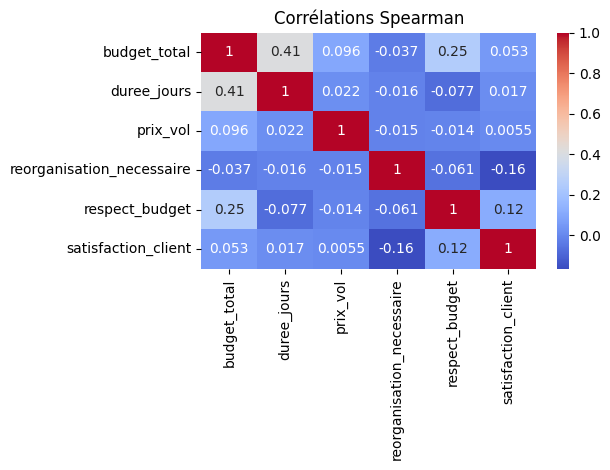

In [120]:
# Heatmap
sns.heatmap(df[colonnes_num].corr(method="spearman"),
            annot=True, cmap="coolwarm")
plt.title("Corrélations Spearman")
plt.tight_layout()
plt.show()

In [121]:
# ANOVA pour les catégorielles
# p_value < 0.05 → influence significative
colonnes_cat = ["client_type", "saison", "meteo_prevue",
                "type_hebergement", "activite_principale", "imprevus"]

print("\nANOVA :")
for col in colonnes_cat:
    groupes    = [df_model[df_model[col] == cat]["satisfaction_client"]
                  for cat in df_model[col].unique()]
    _, p_value = f_oneway(*groupes)
    print(f"{col:25} → p_value : {p_value:.4f} "
          f"{'✅ influence' if p_value < 0.05 else '❌ peu influence'}")


ANOVA :
client_type               → p_value : 0.4764 ❌ peu influence
saison                    → p_value : 0.2895 ❌ peu influence
meteo_prevue              → p_value : 0.4240 ❌ peu influence
type_hebergement          → p_value : 0.1119 ❌ peu influence
activite_principale       → p_value : 0.2941 ❌ peu influence
imprevus                  → p_value : 0.0000 ✅ influence


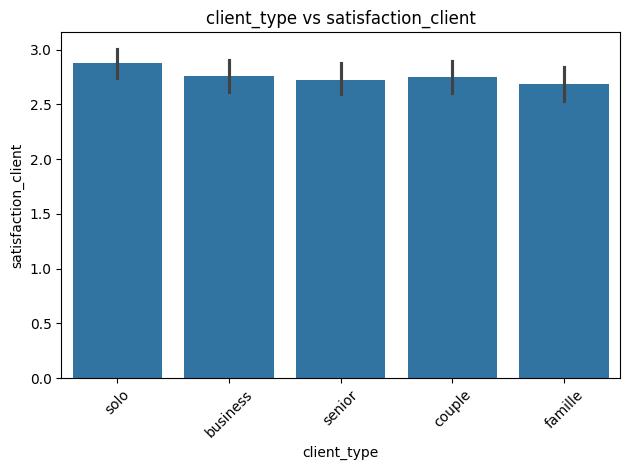

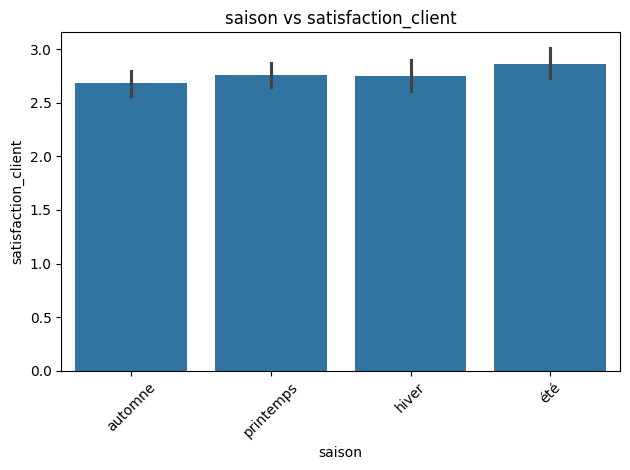

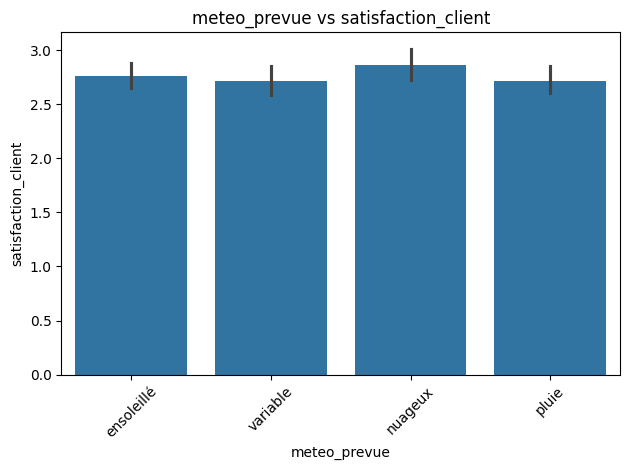

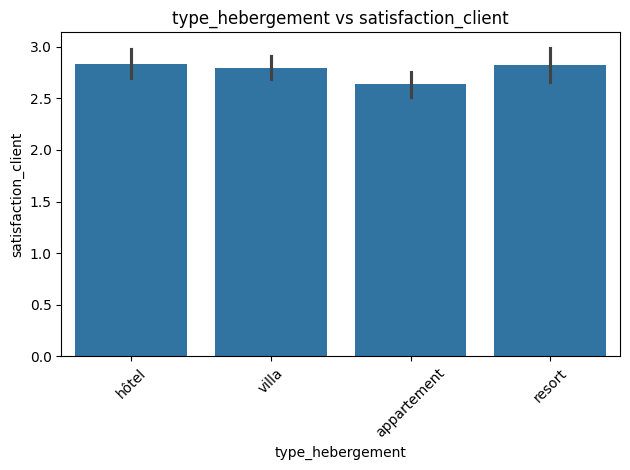

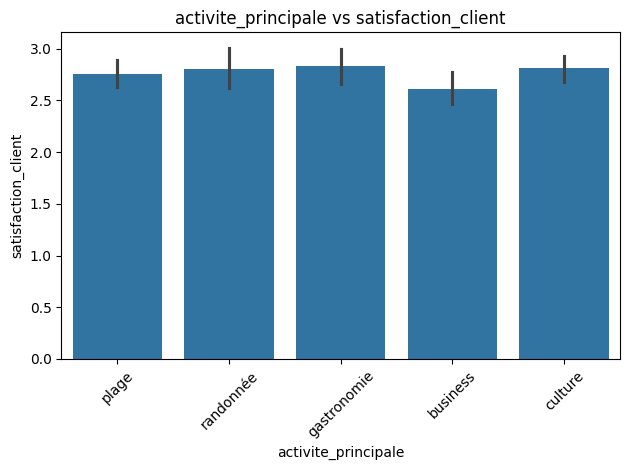

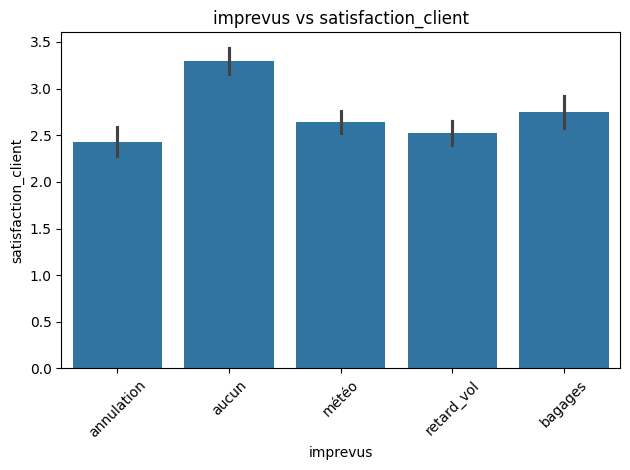

In [122]:
# Barplot — visualiser l'impact de chaque catégorie
# sur satisfaction_client
for col in colonnes_cat:
    sns.barplot(data=df_model, x=col, y="satisfaction_client")
    plt.title(f"{col} vs satisfaction_client")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [123]:
from sklearn.preprocessing import StandardScaler

# StandardScaler ramène toutes les colonnes numériques
# sur la même échelle (moyenne 0, écart-type 1)
# Sans ça le modèle pense que budget_total (6000€)
# est plus important que duree_jours (10 jours)
# juste parce que ses chiffres sont plus grands

scaler = StandardScaler()

# On normalise les colonnes numériques continues
# On ne normalise PAS :
# → reorganisation_necessaire  (déjà 0 ou 1)
# → respect_budget             (déjà 0 ou 1)
# → satisfaction_client        (c'est la target)
# → voyage_long                (déjà 0 ou 1)
# → meteo_risque               (déjà 0 ou 1)
# → saison_haute               (déjà 0 ou 1)
# → client_business            (déjà 0 ou 1)
colonnes_a_normaliser = [
    "budget_total",
    "duree_jours",
    "prix_vol",
    "budget_par_jour",      # feature engineering
    "part_vol_budget",      # Correction: était ratio_vol_budget
    "budget_hors_vol",      # Correction: était budget_jour_hors_vol
]
df_model[colonnes_a_normaliser] = scaler.fit_transform(
    df_model[colonnes_a_normaliser]) # Correction: apply to df_model
# Vérifier — moyenne doit être ~0 et std ~1
print("Après normalisation :")
print(df_model[colonnes_a_normaliser].describe().round(3)) # Correction: apply to df_model
print("\n✅ Normalisation terminée")

Après normalisation :
       budget_total  duree_jours  prix_vol  budget_par_jour  part_vol_budget  \
count      1418.000     1418.000  1418.000         1418.000         1418.000   
mean          0.000       -0.000    -0.000           -0.000           -0.000   
std           1.000        1.000     1.000            1.000            1.000   
min          -1.802       -1.752    -2.763           -2.308           -1.645   
25%          -0.774       -0.710    -0.653           -0.659           -0.732   
50%          -0.136       -0.085    -0.032           -0.062           -0.176   
75%           0.691        0.748     0.650            0.606            0.449   
max           3.041        2.206     2.771            3.284            3.273   

       budget_hors_vol  
count         1418.000  
mean             0.000  
std              1.000  
min             -1.835  
25%             -0.769  
50%             -0.131  
75%              0.716  
max              2.977  

✅ Normalisation terminée


In [124]:
from sklearn.preprocessing import OneHotEncoder

colonnes_cat = [
    "client_type",
    "saison",
    "meteo_prevue",
    "type_hebergement",
    "activite_principale",
    "imprevus"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_array = encoder.fit_transform(df_model[colonnes_cat])

encoded_columns = encoder.get_feature_names_out(colonnes_cat)

df_encoded = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=df_model.index
)

# Correctly update df_model to replace original categorical columns with one-hot encoded ones
df_model = pd.concat(
    [df_model.drop(columns=colonnes_cat, errors='ignore'), df_encoded],
    axis=1
)

print("Colonnes créées :", len(encoded_columns))
df_model.head()

Colonnes créées : 27


,trip_id,budget_total,destination,duree_jours,prix_vol,satisfaction_client,reorganisation_necessaire,respect_budget,retour_client,budget_par_jour,...,activite_principale_business,activite_principale_culture,activite_principale_gastronomie,activite_principale_plage,activite_principale_randonnée,imprevus_annulation,imprevus_aucun,imprevus_bagages,imprevus_météo,imprevus_retard_vol
0,1,-0.442352,Dubaï,-1.543263,0.792013,3.0,1,0,Séjour mitigé.,-0.060236,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,-1.051169,Rome,0.331392,1.601497,4.0,0,1,Excellent séjour.,-1.434923,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,3,1.657826,Bali,1.164571,-0.955114,5.0,1,1,Excellent séjour.,0.596777,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4,-0.038242,Sydney,1.372866,-1.104613,3.0,1,1,Séjour mitigé.,-0.924803,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,5,0.113516,Paris,-0.710083,-0.161635,2.0,1,1,Séjour mitigé.,1.515691,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [125]:
!python -m spacy download fr_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 MB 3.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [126]:
import spacy
from transformers import pipeline

# Charger les modèles
# fr_core_news_lg → modèle français large → plus précis
# CamemBERT → analyse le sentiment directement en français
# Précision ~93%
nlp       = spacy.load("fr_core_news_lg")
analyseur = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

# Étape 1 — Tokenisation : découper le texte en mots
def etape1(texte):
    doc = nlp(str(texte))
    return [token.text for token in doc]

# Étape 2 — Stop words : enlever les mots inutiles
def etape2(texte):
    doc = nlp(str(texte))
    return [token.text for token in doc
            if not token.is_stop
            and not token.is_punct]

# Étape 3 — Lemmatisation : ramener à la forme de base
# "livré" → "livrer" / "jours" → "jour"
def etape3(texte):
    doc = nlp(str(texte))
    return " ".join([token.lemma_ for token in doc])

# Étape 4 — POS Tagging : identifier adjectifs et noms
# les adjectifs portent le sentiment
# les noms portent les thèmes
def etape4(texte):
    doc = nlp(str(texte))
    return [token.text for token in doc
            if token.pos_ in ["ADJ", "NOUN"]]

# Étape 5 — NER : détecter marques, lieux, dates
def etape5(texte):
    doc = nlp(str(texte))
    return [ent.text for ent in doc.ents]

# Étape 6 — Sentiment avec CamemBERT
# retourne score (0 à 5) et label (positif/négatif/neutre)
def etape6(texte):
    # Mappage des étoiles vers un score numérique (0-5) et un label de sentiment
    star_to_numeric = {
        "1 star": 0.0,
        "2 stars": 1.0,
        "3 stars": 2.5,
        "4 stars": 4.0,
        "5 stars": 5.0
    }
    sentiment_label_mapping = {
        "1 star": "négatif",
        "2 stars": "négatif",
        "3 stars": "neutre",
        "4 stars": "positif",
        "5 stars": "positif"
    }

    # texte vide → neutre par défaut (score 2.5)
    if str(texte).strip() == "":
        return 2.5, "neutre"
    try:
        resultat = analyseur(str(texte))[0]
        label    = resultat["label"]

        score = star_to_numeric.get(label, 2.5) # Par défaut 2.5 si l'étiquette n'est pas reconnue
        sentiment = sentiment_label_mapping.get(label, "neutre")

        return score, sentiment
    except Exception as e:
        # En cas d'erreur, retourner un score neutre et le label 'neutre'
        print(f"Erreur lors de l'analyse de sentiment pour le texte: '{texte[:50]}...' - {e}")
        return 2.5, "neutre"

# Appliquer les 6 étapes sur toute la colonne
df_model["tokens"]         = df_model["retour_client"].apply(etape1)
df_model["mots_utiles"]    = df_model["retour_client"].apply(etape2)
df_model["mots_propres"]   = df_model["retour_client"].apply(etape3)
df_model["mots_cles"]      = df_model["retour_client"].apply(etape4)
df_model["entites"]        = df_model["retour_client"].apply(etape5)
df_model["score_avis"]     = df_model["retour_client"].apply(lambda x: etape6(x)[0])
df_model["sentiment_avis"] = df_model["retour_client"].apply(lambda x: etape6(x)[1])

# Encoder sentiment_avis en chiffres
# Mapping manuel pour éviter les problèmes d'accent
mapping = {"négatif": 0, "neutre": 1, "positif": 2}
df_model["sentiment_avis"] = df_model["sentiment_avis"].map(mapping)

# Vérifier
print(df_model[["retour_client", "score_avis",
          "sentiment_avis"]].drop_duplicates())
print("\n✅ NLP terminé")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                            retour_client  score_avis  sentiment_avis
0                          Séjour mitigé.         2.5               1
1                       Excellent séjour.         5.0               2
750     De nombreux problèmes rencontrés.         1.0               0
751             Très mauvaise expérience.         0.0               0
753         Dans l'ensemble satisfaisant.         4.0               2
756               Parfait, rien à redire.         5.0               2
757        Très satisfait, je recommande.         5.0               2
758           Une expérience inoubliable.         5.0               2
762                 Je ne recommande pas.         0.0               0
763        Très bon rapport qualité-prix.         5.0               2
764  Quelques imprévus, globalement bien.         2.5               1
766                                               2.5               1
798              Déçu par l'organisation.         1.0               0
832      Séjour corr

In [127]:
from sklearn.cluster import KMeans
import pandas as pd # Ensure pandas is imported as it's needed for is_numeric_dtype

# KMeans regroupe les clients similaires en 3 segments
# segment 0 → voyageurs économiques
# segment 1 → voyageurs moyens
# segment 2 → voyageurs premium
# La colonne segment_client devient une feature pour le ML

# Define numerical columns for KMeans (these should already be in df_model)
colonnes_numeriques_for_kmeans = [
    "budget_total", "duree_jours", "prix_vol",
    "budget_par_jour", "part_vol_budget", "budget_hors_vol",
    "reorganisation_necessaire", "respect_budget",
    "voyage_long", "meteo_risque", "saison_haute", "client_business",
    "score_avis", "sentiment_avis"
]

# Get all one-hot encoded columns that are now in df_model
one_hot_columns_in_df_model = [col for col in df_model.columns if col.startswith(('client_type_', 'saison_', 'meteo_prevue_', 'type_hebergement_', 'activite_principale_', 'imprevus_'))]

# Combine numerical and one-hot encoded columns for clustering
final_features_for_kmeans = list(set(colonnes_numeriques_for_kmeans + one_hot_columns_in_df_model))

# Filter to ensure all selected columns exist in df_model
final_features_for_kmeans = [col for col in final_features_for_kmeans if col in df_model.columns]

# Select the subset of data for clustering
# Make a copy to avoid potential SettingWithCopyWarning if imputation is done inplace
X_cluster = df_model[final_features_for_kmeans].copy()

# Debug: Print NaNs before final imputation
print("NaNs in X_cluster BEFORE final imputation:")
nan_cols_before = X_cluster.isnull().sum()
print(nan_cols_before[nan_cols_before > 0])

# Impute any remaining NaNs directly on X_cluster if any are still present
if X_cluster.isnull().any().any(): # Check if there are any NaNs in the entire DataFrame
    print("\nPerforming final NaN imputation on X_cluster...")
    for col in X_cluster.columns:
        if X_cluster[col].isnull().any():
            if pd.api.types.is_numeric_dtype(X_cluster[col]):
                median_val = X_cluster[col].median()
                if pd.isna(median_val): # If median is NaN (e.g., column is all NaNs), impute with 0 or a sensible default
                    print(f"Warning: Median for column '{col}' is NaN. Imputing with 0.")
                    X_cluster[col].fillna(0, inplace=True)
                else:
                    X_cluster[col].fillna(median_val, inplace=True)
            else:
                # This path should ideally not be taken for one-hot encoded features unless something went wrong earlier
                # For non-numeric, if NaNs exist, mode imputation is reasonable.
                mode_val = X_cluster[col].mode()[0]
                X_cluster[col].fillna(mode_val, inplace=True)

# Debug: Print NaNs after final imputation
print("\nNaNs in X_cluster AFTER final imputation:")
nan_cols_after = X_cluster.isnull().sum()
print(nan_cols_after[nan_cols_after > 0])
if nan_cols_after.sum() == 0:
    print("No NaNs remaining in X_cluster.")

# 3 groupes → économique, moyen, premium
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
segment_client_labels = kmeans.fit_predict(X_cluster)

# Add the new 'segment_client' column to the main df_model
df_model.loc[X_cluster.index, "segment_client"] = segment_client_labels # Use .loc for alignment

# Vérifier la répartition
print("Répartition des segments :")
print(df_model["segment_client"].value_counts())

# Profil moyen de chaque segment
print("\nProfil moyen par segment (colonnes numériques et encodées) :")
print(df_model.groupby("segment_client")[final_features_for_kmeans].mean().round(2))

print("\n✅ Clustering terminé")

NaNs in X_cluster BEFORE final imputation:
Series([], dtype: int64)

NaNs in X_cluster AFTER final imputation:
Series([], dtype: int64)
No NaNs remaining in X_cluster.
Répartition des segments :
segment_client
2.0    522
0.0    459
1.0    437
Name: count, dtype: int64

Profil moyen par segment (colonnes numériques et encodées) :
                voyage_long  activite_principale_culture  score_avis  \
segment_client                                                         
0.0                    0.47                         0.32        1.76   
1.0                    0.26                         0.34        4.92   
2.0                    0.11                         0.27        2.12   

                client_type_business  meteo_risque  saison_hiver  \
segment_client                                                     
0.0                             0.11          0.47          0.19   
1.0                             0.23          0.42          0.20   
2.0                             0.36

In [128]:
# Supprimer les colonnes inutiles pour le ML
# retour_client → remplacé par score_avis et sentiment_avis
# trip_id       → identifiant inutile
# destination   → trop de valeurs uniques
# tokens, mots_utiles, mots_propres, mots_cles, entites
#               → étapes intermédiaires NLP

X = df.drop(columns=[
    "satisfaction_client",  # c'est la target → y
    "retour_client",        # texte brut → remplacé par NLP
    "trip_id",              # identifiant inutile
    "destination",          # trop de valeurs uniques
    "tokens",               # étapes intermédiaires NLP
    "mots_utiles",          # étapes intermédiaires NLP
    "mots_propres",         # étapes intermédiaires NLP
    "mots_cles",            # étapes intermédiaires NLP
    "entites"               # étapes intermédiaires NLP
])

# Target — ce que le modèle doit prédire
y = df["satisfaction_client"]

print(f"Features : {list(X.columns)}")
print(f"Shape X  : {X.shape}")
print(f"Shape y  : {y.shape}")

KeyError: "['tokens', 'mots_utiles', 'mots_propres', 'mots_cles', 'entites'] not found in axis"

In [ ]:
# Supprimer les colonnes inutiles pour le ML
cols_to_drop_from_X = [
    "satisfaction_client",  # c'est la target → y
    "retour_client",        # texte brut → remplacé par score_avis et sentiment_avis
    "trip_id",              # identifiant inutile
    "destination",          # trop de valeurs uniques
    "tokens",               # étapes intermédiaires NLP
    "mots_utiles",          # étapes intermédiaires NLP
    "mots_propres",         # étapes intermédiaires NLP
    "mots_cles",            # étapes intermédiaires NLP
    "entites",              # étapes intermédiaires NLP
    # Ajout des colonnes catégorielles originales qui ont été one-hot encodées
    "client_type",
    "saison",
    "meteo_prevue",
    "type_hebergement",
    "activite_principale",
    "imprevus"
]

X = df_model.drop(columns=cols_to_drop_from_X, errors='ignore')

X = X.drop(columns=["score_avis"], errors='ignore') # Assuming score_avis is dropped in favor of sentiment_avis

# Target — ce que le modèle doit prédire
y = df_model["satisfaction_client"]

print(f"Features : {list(X.columns)}")
print(f"Shape X  : {X.shape}")
print(f"Shape y  : {y.shape}")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Séparer en train (80%) et test (20%)
# random_state=42 → résultats reproductibles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

# Modèle 1 — Random Forest
# robuste aux outliers, pas besoin de normalisation
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Modèle 2 — XGBoost
# plus performant sur les données tabulaires
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Comparer les résultats
# MAE   → erreur moyenne en points (ex: 0.8 point d'erreur)
# R²    → % de variance expliquée (1.0 = parfait)
# Score → précision sur les données de test (0 à 1)
print("\n=== RÉSULTATS RÉGRESSION ===")
for nom, modele, y_pred in [
    ("Random Forest", rf,  y_pred_rf),
    ("XGBoost",       xgb, y_pred_xgb)
]:
    print(f"\n{nom} :")
    print(f"  MAE   : {mean_absolute_error(y_test, y_pred):.3f}")
    print(f"  R²    : {r2_score(y_test, y_pred):.3f}")
    print(f"  Score : {modele.score(X_test, y_test):.3f}")

print("\n✅ Régression terminée")

In [ ]:
display(df_model)

définition de la cible et des variables explicatives

In [ ]:
target_column = "satisfaction_client"
# X et y sont déjà définis par la cellule y1HqP2o2S9E0
# Les colonnes post_trip et techniques ont déjà été gérées lors de la création de X

class_labels = sorted(y.unique())

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

# La liste excluded_columns peut être redéfinie pour la documentation si nécessaire,
# mais elle n'impacte plus la construction de X ici.
excluded_columns_for_display = [
    target_column,
    "trip_id",              # identifiant inutile
    "destination",          # trop de valeurs uniques
    "retour_client",        # texte brut → remplacé par score_avis et sentiment_avis
    "tokens",               # étapes intermédiaires NLP
    "mots_utiles",          # étapes intermédiaires NLP
    "mots_propres",         # étapes intermédiaires NLP
    "mots_cles",            # étapes intermédiaires NLP
    "entites",              # étapes intermédiaires NLP
    # Ajout des colonnes catégorielles originales qui ont été one-hot encodées
    "client_type",
    "saison",
    "meteo_prevue",
    "type_hebergement",
    "activite_principale",
    "imprevus",
    "score_avis" # Dropped in favor of sentiment_avis
]

variables_resume = pd.DataFrame({
    "famille": ["numériques", "catégorielles", "exclues", "cible"],
    "nombre": [len(numeric_features), len(categorical_features), len(excluded_columns_for_display), 1],
    "colonnes": [numeric_features, categorical_features, excluded_columns_for_display, [target_column]],
})

display(variables_resume)
print("Distribution de la cible :")
display(y.value_counts(normalize=True).sort_index().rename("proportion"))

analyse après nettoyage

In [ ]:
correlation_columns = [column for column in numeric_features if column != target_column]
correlation_df = df_model[correlation_columns + [target_column]].copy()

spearman_target = (
    correlation_df.corr(method="spearman")[target_column]
    .drop(target_column)
    .sort_values(key=lambda serie: serie.abs(), ascending=False)
)

display(spearman_target.to_frame("correlation_spearman_satisfaction"))

In [ ]:
for column in ["client_type", "destination", "saison", "type_hebergement", "meteo_prevue", "activite_principale"]:
    if column in df_model.columns:
        print(f"\nSatisfaction moyenne par {column}")
        display(
            df_model.groupby(column, dropna=False)[target_column]
            .agg(nb_sejours="count", satisfaction_moyenne="mean")
            .round(2)
            .sort_values("satisfaction_moyenne", ascending=False)
        )

pipeline de transformation

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="inconnu"),
    OneHotEncoder(handle_unknown="ignore"),
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

preprocessor

modèle baseline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

baseline_pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)

baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy baseline : {baseline_accuracy:.4f}")

In [ ]:
print(classification_report(y_test, y_pred, labels=class_labels))

In [ ]:
confusion = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=class_labels),
    index=[f"réel_{label}" for label in class_labels],
    columns=[f"prédit_{label}" for label in class_labels],
)

display(confusion)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — baseline")
plt.tight_layout()
plt.show()

visualsation de contrôle

In [ ]:
plot_columns = [
    column
    for column in ["budget_total", "prix_vol", "duree_jours", "budget_par_jour", "part_vol_budget", "satisfaction_client"]
    if column in df_model.columns
]

fig, axes = plt.subplots(len(plot_columns), 1, figsize=(8, 3 * len(plot_columns)))
if len(plot_columns) == 1:
    axes = [axes]

for axis, column in zip(axes, plot_columns):
    sns.histplot(df_model[column], kde=True, ax=axis)
    axis.set_title(column)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_model[numeric_features + [target_column]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="viridis")
plt.title("Corrélations numériques après nettoyage")
plt.tight_layout()
plt.show()

In [ ]:
print("Colonnes disponibles dans df_model :")
print(df_model.columns.tolist())